# Attention is all you need instead of love exploration☠️

## What is attention mechanism?

To answer this question, let's start with some back story.

Back in 2014 when researchers are working on an text translation model which require contextual understanding and grammar alignment.

They invented `encoder-decoder` model, in which `encoder` reads and processes the text, whereas `decoder` translates text.

Translations before `transformer` use `RNN(Recurrent Neural Network)` for the most popular encoder-decoder language translation model, which basically means output from the previous step is fed to current text to **update a hidden state** at each step with the upcoming new word. The model will use the final hidden state to generate translate sentence **one word at a time**

There is certainly a problem here, you may have also spotted: Since RNN cannot directly access previous hidden state from the encoder during the training phase, **it relies only on current hidden state**. Therefore this leads to a **loss of context**, especially in complex sentences where dependencies might span long distances, like:

- *The **cat** that was sitting on the mat, which was next to the dog, **jumped.***

Attention come to resolve this problem!

### Attention here means
<div class='alert alert-block alert-info'>
The mechanism's ability to compute attention weights by relating different positions in a single input sequence.
</div>

## 1. Simplified Attention Mechanism


Let's start by implementing a compact self attention python class, then to clarify every single component in this class.

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

- Each row represents a word.
- Each column represents an embedding dimension.

Let's start with a compact **self-attention** python class.

In [ ]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
        # Initiating random Q,K,V matrices, which are going to be optimized

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        # Resulting matrices = inputs * corresponding matrices

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec


In this PyTorch code, **SelfAttention_v1** is a class derived from **nn.Module**, which is a
**fundamental building block** of PyTorch models, which provides necessary functionalities for
model layer creation and management.


The `__init__` method initializes trainable weight matrices `W_query`, `W_key`, and `W_value` for queries, keys, and values, each **transforming** the input dimension d_in to an
output dimension d_out.


During the forward pass, using the forward method, we compute the **attention scores**
(`attn_scores`) by multiplying queries and keys transposed, **normalizing** these scores using softmax.

    
Finally, we create a **context vector** by weighting the values with these normalized attention
scores.


In [ ]:
torch.manual_seed(123)
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


Since inputs contains six embedding vectors, we get a matrix storing the six
**context vectors**, as shown in the above result. 


We can improve the `SelfAttention_v1` implementation further by utilizing PyTorch's
`nn.Linear` layers, which effectively perform matrix multiplication when the bias units are
disabled. 


Additionally, a significant advantage of using `nn.Linear` instead of manually
implementing `nn.Parameter(torch.rand(...))` is that nn.Linear has an **optimized** weight
initialization scheme, contributing to more stable and effective model training.



In [ ]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        # We project the input into three different representations: keys, queries, and values. 

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec


In [9]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


Note that `SelfAttention_v1` and `SelfAttention_v2` give different output trends because they
use **different initial weights** for the weight matrices since ``nn.Linear`` uses a more
sophisticated weight initialization scheme.

### **Clarifications**

#### What is Query, Keys and Values?

- **Query** represents the current token that the model focuses on.
- **Key** are used to match with the query.
- **Value** represents the actual content or representation of the input items. Once the model determines which keys(which parts of the input) are most relavent to the query(current focus item), it retrives the corresponding values.

---

- **Imagine a library**:  
  - A **query** is the question you ask the librarian.  
  - A **key** is the index entry for each book.  
  - A **value** is the actual content inside each book.  
  You compare your question (query) to the index entries (keys) to decide which books (values) to read and how much attention to give each. 



#### What is projection here mean?

In ethis case, we initialted random `nn.Linear` layers for Q, K, and V, so when we use `keys = self.W_key(x)`, x is basically going through `y = x*W + b`, in which `x` is input vector, `W` is weight, while `b` is bias. 

#### Why `-1`?

- `keys.shape[-1]` means the last dimension, which is the dimension of vector.
- `dim=-1` means perfoming softmax at the last dimension.

So when we implement multihead attention later where the dimension could change, this piece of code is still usable.

#### Why `sqrt(dimension)`?

- `softmax()` is sensitive to magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input become much more pronounced, causing the `softmax` output to become 'peaky', where the highest value receives almost all the probability mass, and the rest receives very little. Model will therefore be confident in one particular `key`

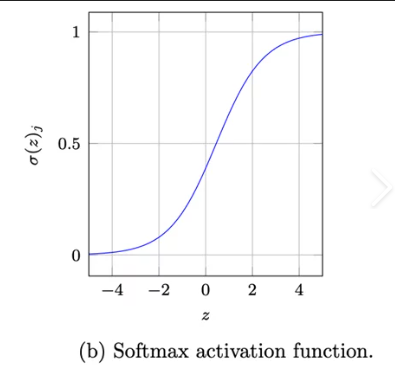

- The dot product of Q and K increases the variance beacuse mulpliplying 2 random numbers increases the variance. The increase in variance grows with dimension. dividing by `sqrt(dimension)` keeps the variance close to 1.